# Lab 1: Linear Regression

Виконав студент 3-го курсу, групи КН-42, Пишко Олександр

**Мета:** навчитись реалізовувати лінійну регресію та градієнтний спуск у матричному вигляді.

**Теоретична основа:**
Лінійна регресія з однією змінною описується рівнянням:
$$ \hat{y} = w_0 + w_1 x $$
Щоб не працювати окремо з коефіцієнтом $w_0$ та зміщенням, або bias $b$, ми можемо додати до набору ознак фіктивну ознаку $x_0 = 1$. Тоді рівняння можна записати у векторному вигляді як скалярний добуток:
$$ \hat{y} = X \cdot W $$
Де $X$ — матриця ознак, до якої додано стовпець одиниць, а $W = [w_0, w_1]^T$ — вектор ваг.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import csv

### 1. Зчитування даних

Під час завантаження даних ми одразу додамо до матриці ознак $X$ додатковий стовпець, який складається виключно з одиниць. Це дозволить нам об'єднати вагу $w_1$ та bias $w_0$ в один вектор $W$.

$$ X = \begin{pmatrix} 1 & x^{(1)} \\ 1 & x^{(2)} \\ \vdots & \vdots \\ 1 & x^{(n)} \end{pmatrix}, \quad Y = \begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix} $$

In [9]:
def load_data(filename):
    x, y = [], []
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            x.append(float(row[1]))
            y.append(float(row[2]))
    
    x = np.array(x)
    y = np.array(y)
    
    X = np.column_stack((np.ones(len(x)), x))
    return X, y

X_train, y_train = load_data('lab_1_train.csv')
X_test, y_test = load_data('lab_1_test.csv')

### 2. Візуалізація даних з lab_1_train.csv

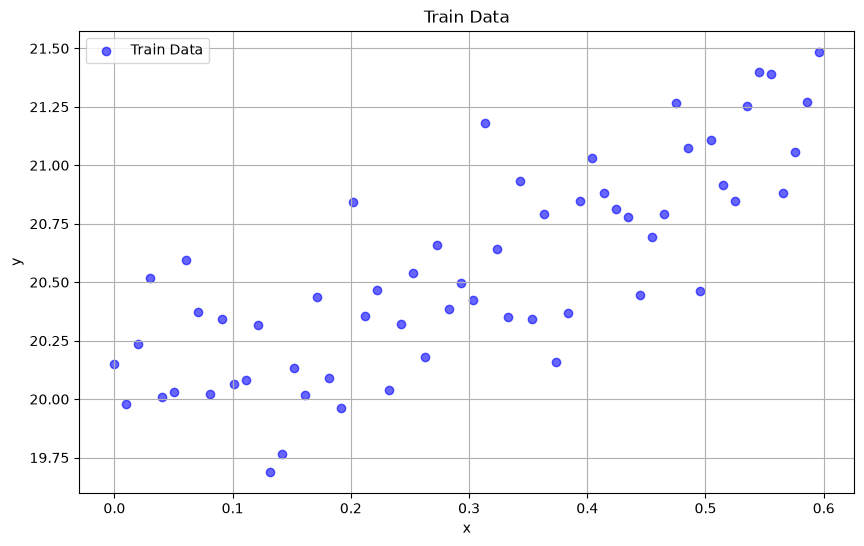

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 1], y_train, color='blue', alpha=0.6, label='Train Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Train Data')
plt.legend()
plt.grid(True)
plt.show()

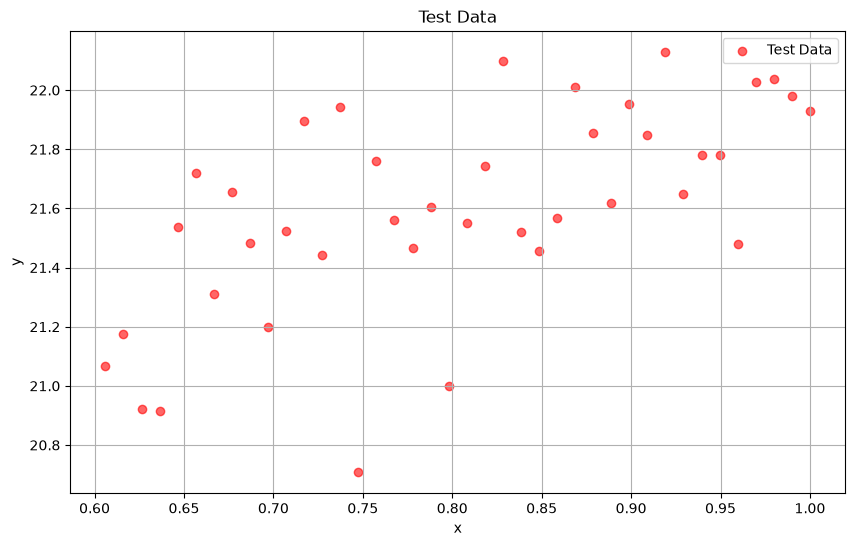

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 1], y_test, color='red', alpha=0.6, label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Test Data')
plt.legend()
plt.grid(True)
plt.show()

### 3. Функція втрат
У якості функції втрат використовується середньоквадратична помилка (Mean Squared Error). Математично вона записується так:
$$ L(W) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2 = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - X^{(i)} W)^2 $$
У векторному вигляді:
$$ MSE = \frac{1}{n} \|Y - \hat{Y}\|^2 $$

In [12]:
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

### 4. Реалізація батчевого градієнтного спуску

Градієнтний спуск шукає мінімум функції втрат, рухаючись у напрямку, протилежному до градієнта. Оскільки ми використовуємо матричний підхід, ми можемо знайти градієнт по відношенню до всього вектора ваг одразу.

Вектор градієнтів $\nabla L(W)$:
$$ \nabla L(W) = -\frac{2}{n} X^T (Y - \hat{Y}) $$

Оновлення ваг відбувається за правилом:
$$ W = W - \alpha \nabla L(W) $$
де $\alpha$ — швидкість навчання.

In [24]:
W = np.zeros(2) 

learning_rate = 0.5
epochs = 250
n = len(X_train)

print(f"{'Епоха':<10} | {'w0 (bias)':<15} | {'w1':<15} | {'MSE':<15}")
print("-" * 56)

for epoch in range(1, epochs + 1):
    y_pred = X_train.dot(W)
    
    dW = (-2 / n) * X_train.T.dot(y_train - y_pred)
    
    W -= learning_rate * dW
    
    loss = compute_mse(y_train, X_train.dot(W))
    print(f"{epoch:<10} | {W[0]:<15.5f} | {W[1]:<15.5f} | {loss:<15.5f}")
    print("-" * 56)

Епоха      | w0 (bias)       | w1              | MSE            
--------------------------------------------------------
1          | 20.54956        | 6.18391         | 4.00961        
--------------------------------------------------------
2          | 18.70688        | 5.50615         | 0.49456        
--------------------------------------------------------
3          | 18.90884        | 5.45839         | 0.44374        
--------------------------------------------------------
4          | 18.92307        | 5.35615         | 0.42301        
--------------------------------------------------------
5          | 18.95354        | 5.26188         | 0.40366        
--------------------------------------------------------
6          | 18.98163        | 5.16978         | 0.38538        
--------------------------------------------------------
7          | 19.00907        | 5.08031         | 0.36811        
--------------------------------------------------------
8          | 19.03573   

### 5. Обчислення функції втрат на тестових даних
Після того як градієнтний спуск зійшовся і ми знайшли оптимальні ваги $W$, перевіримо точність моделі на тестових даних.

In [25]:
y_test_pred = X_test.dot(W)
test_loss = compute_mse(y_test, y_test_pred)
print(f"Test MSE: {test_loss:.5f}")

Test MSE: 0.07545


### 6. Візуалізація результатів
Візуалізуємо дані тренувальної та тестової вибірок на одному графіку, а також побудуємо фінальну лінію, яка описує наші дані:
$$ y = W_0 + W_1 x $$

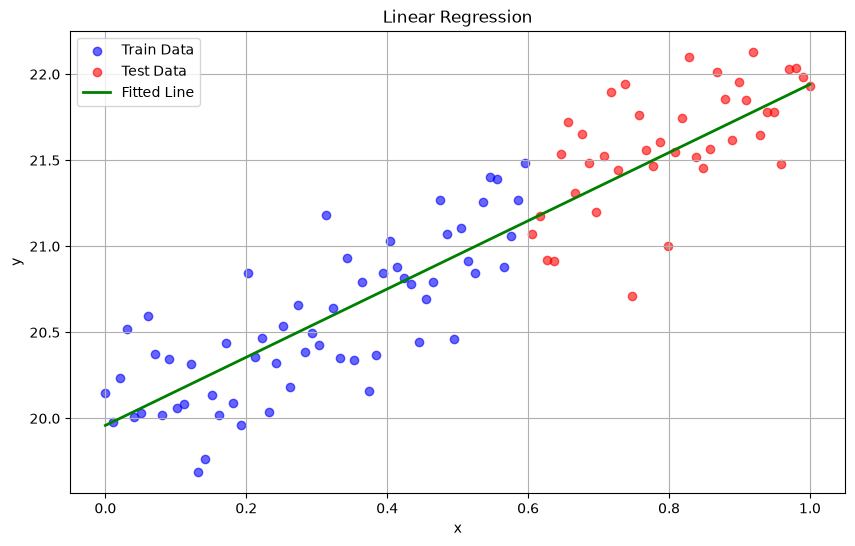

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 1], y_train, color='blue', alpha=0.6, label='Train Data')
plt.scatter(X_test[:, 1], y_test, color='red', alpha=0.6, label='Test Data')

x_vals = np.linspace(min(np.min(X_train[:, 1]), np.min(X_test[:, 1])), 
                     max(np.max(X_train[:, 1]), np.max(X_test[:, 1])), 100)

X_line = np.column_stack((np.ones(len(x_vals)), x_vals))
y_line = X_line.dot(W)

plt.plot(x_vals, y_line, color='green', linewidth=2, label='Fitted Line')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

### Висновок
У ході виконання лабораторної роботи було реалізовано алгоритм лінійної регресії з використанням класичного градієнтного спуску. Завдяки застосуванню матричного підходу додавання фіктивної ознаки $x_0 = 1$ вдалося об'єднати вагу $w_1$ та зміщення баяса $w_0$ в єдиний вектор ваг $W$, що значно спростило обчислення градієнтів та оновлення параметрів.

Аналіз результатів демонструє, що в процесі навчання функція втрат стабільно зменшувалась, що свідчить про коректну роботу алгоритму та правильно підібраний крок навчання. Значення помилки на тестовому датасеті виявилося близьким до помилки на тренувальному, що вказує на відсутність перенавчання та хорошу здатність моделі до генералізації.

Побудована пряма на графіку візуально підтверджує, що знайдений розв'язок адекватно описує лінійну залежність між вхідною змінною $x$ та цільовою змінною $y$.